In [81]:
import numpy as np
import pandas as pd

In [82]:
df = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
TARGET_COL = 'loan_paid_back'
df = df.drop('id', axis=1)

# Pre-Processing

In [83]:
df.shape

(593994, 12)

In [84]:
df.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 54.4+ MB


In [86]:
df.isnull().sum()

annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

## Feature Engineering

In [87]:
categorical_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        categorical_cols.append(col)

categorical_cols

['gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade']

In [88]:
from sklearn.preprocessing import LabelEncoder, normalize
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.sample(10)
# normalize(df, norm='l2')

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
293741,57735.46,0.179,668,19015.21,13.35,0,1,3,2,2,19,1.0
60176,20774.57,0.207,536,9607.62,13.94,0,1,0,0,2,29,1.0
488325,76477.13,0.107,644,22199.36,9.30,0,2,1,1,0,15,1.0
432534,147548.28,0.090,683,10941.43,10.72,0,2,0,0,2,11,1.0
190485,63669.84,0.050,692,16978.87,13.91,0,2,1,0,2,10,1.0
530122,45923.31,0.099,724,25753.65,11.49,0,0,0,0,1,12,1.0
332426,37464.00,0.039,695,25194.72,11.10,0,1,0,0,2,14,1.0
485004,44861.06,0.079,624,8146.24,13.74,1,1,0,3,2,17,0.0
97626,35259.98,0.058,775,24267.99,10.86,1,1,0,0,2,8,1.0
410017,35435.90,0.048,697,11589.56,11.10,0,2,0,2,2,14,1.0


## Data Visualization

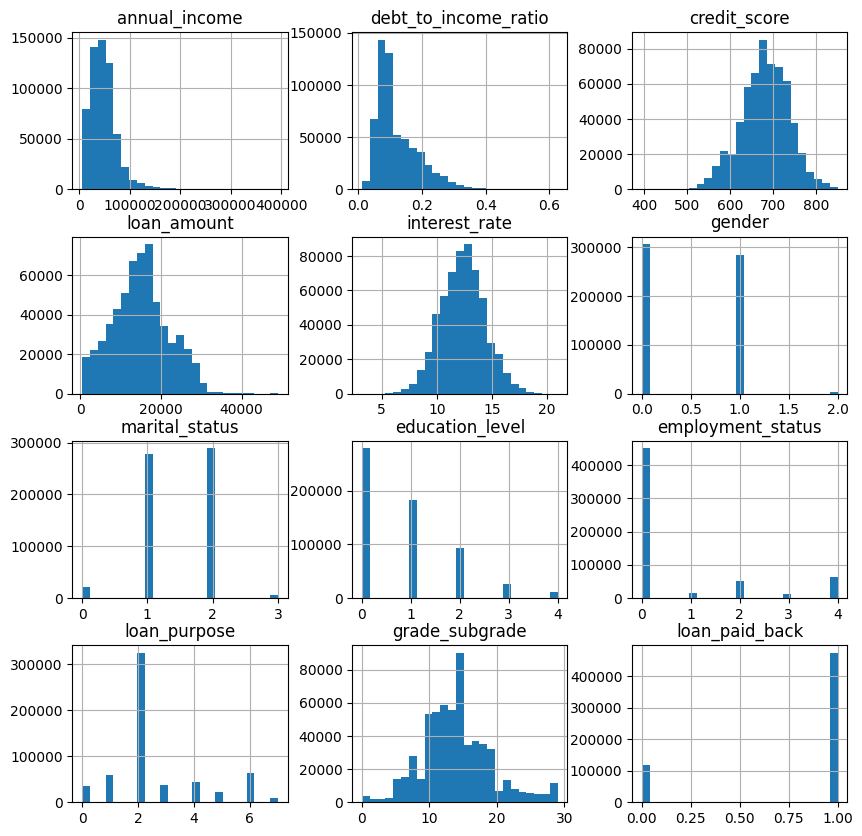

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(bins=25, figsize=(10, 10))
plt.show()

<Axes: >

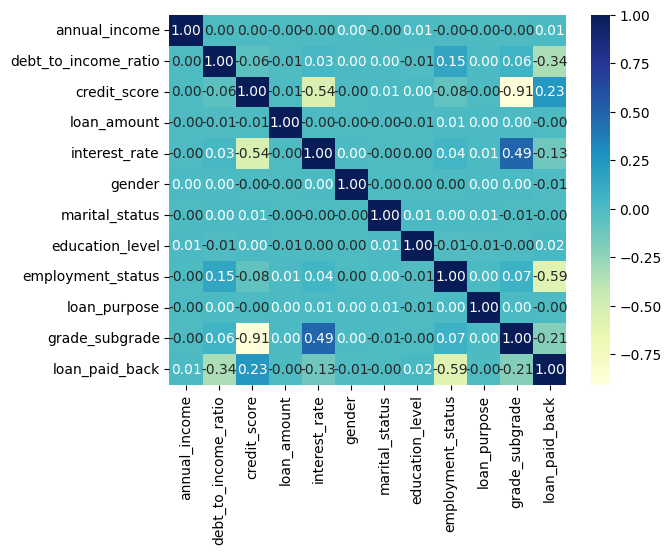

In [90]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu')

In [91]:
relations = corr_matrix[TARGET_COL]
relations

annual_income           0.006326
debt_to_income_ratio   -0.335680
credit_score            0.234560
loan_amount            -0.003762
interest_rate          -0.131184
gender                 -0.007356
marital_status         -0.000404
education_level         0.018781
employment_status      -0.585304
loan_purpose           -0.000973
grade_subgrade         -0.212376
loan_paid_back          1.000000
Name: loan_paid_back, dtype: float64

In [92]:
attributes = []
for i in range(len(relations)):
    if abs(relations.iloc[i]) > 0.01 and relations.index[i] != 'loan_paid_back':
        attributes.append(relations.index[i])

attributes

['debt_to_income_ratio',
 'credit_score',
 'interest_rate',
 'education_level',
 'employment_status',
 'grade_subgrade']

In [93]:
data = df[attributes]
label = df[TARGET_COL]

## Train/Validation Split

In [94]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(data, label, test_size=0.2)

# Models

In [95]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

clf = DecisionTreeClassifier().fit(X_train, y_train)
y_proba = clf.predict(X_val)
roc_auc_score(y_val, y_proba)

np.float64(0.7726087453865463)

## Test Dataset

In [96]:
test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
ids = test['id']

for col in categorical_cols:
     test[col] = le.fit_transform(test[col])

test = test[attributes]

test.sample(5)

,debt_to_income_ratio,credit_score,interest_rate,education_level,employment_status,grade_subgrade
94794,0.194,628,12.67,0,0,15
185350,0.182,593,16.44,2,4,20
55050,0.190,618,15.32,0,0,18
101982,0.217,716,12.35,1,0,12
232475,0.054,583,13.13,1,4,24


In [97]:
X_train.sample(5)

,debt_to_income_ratio,credit_score,interest_rate,education_level,employment_status,grade_subgrade
45773,0.228,679,15.57,0,0,10
298259,0.141,642,12.51,0,0,17
422769,0.096,721,12.86,2,4,10
131973,0.071,704,11.91,0,0,13
539363,0.084,697,8.04,1,0,10


In [98]:
clf = DecisionTreeClassifier().fit(X_train, y_train)
y_test = clf.predict(test)
y_test

array([1., 1., 0., ..., 1., 1., 1.])

# Submission

In [103]:
submission_df = pd.DataFrame({'id': ids.values,
                             'loan_paid_back': y_test})

submission_df.to_csv('/kaggle/working/submission.csv', index=False)